In [1]:
                     #30 ocean

                   #7 and #1 at the sea-ice edge

                       #17
            
            
#32 + (no readable)                     #22 + #2

#10 + #8                                #27 + #25 + #4

#23 #18 #26


#9 #13



# EVENT 18th April + 24th April


In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd  

In [17]:
OMBraw = xr.open_mfdataset('/home/maltem/work/python/data/SvalMIZ2024/cruise/2024_KVS_deployment.nc')

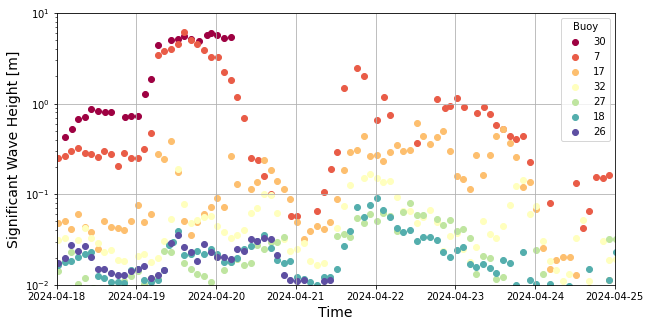

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # For datetime conversion
import matplotlib.cm as cm

# Define the time range for the plot
start_time = pd.to_datetime("2024-04-18")
end_time = pd.to_datetime("2024-04-25")

# List of buoy numbers
buoy_list = [30, 7, 1, 17, 32, 10, 8, 23, 18, 26, 9, 13]
buoy_list = [30,7,1,17,22,2,27,25,4]
buoy_list = [30,7,17, 32,27,18,26]
# Create a colormap (light blue to dark blue)
colors = cm.Spectral(np.linspace(0, 1, len(buoy_list)))  # Generate a color map

# Plot the time series
plt.figure(figsize=(10, 5))

for i, buoyno in enumerate(buoy_list):
    # Assign color based on the buoy position in the list
    color = colors[i]
    plt.scatter(OMBraw.time_waves_imu[buoyno, :], OMBraw.Hs0[buoyno, :], label=str(buoyno), color=color)

# Limit the time range in the plot
plt.xlim([start_time, end_time])
plt.ylim([0.01, 10])

# Set logarithmic scale on the y-axis
plt.yscale('log')

# Add labels and grid
plt.xlabel("Time",fontsize=14)
plt.ylabel("Significant Wave Height [m]", fontsize=14)
plt.legend(title="Buoy")
plt.grid(True)


# Save the plot as a PNG file
plt.savefig("timeseries_plot_cc.png", dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

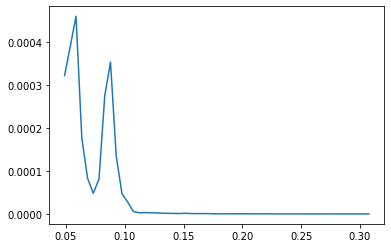

In [62]:
plt.plot(OMBraw.frequencies_waves_imu,OMBraw.processed_elevation_energy_spectrum[18,300,:].values)

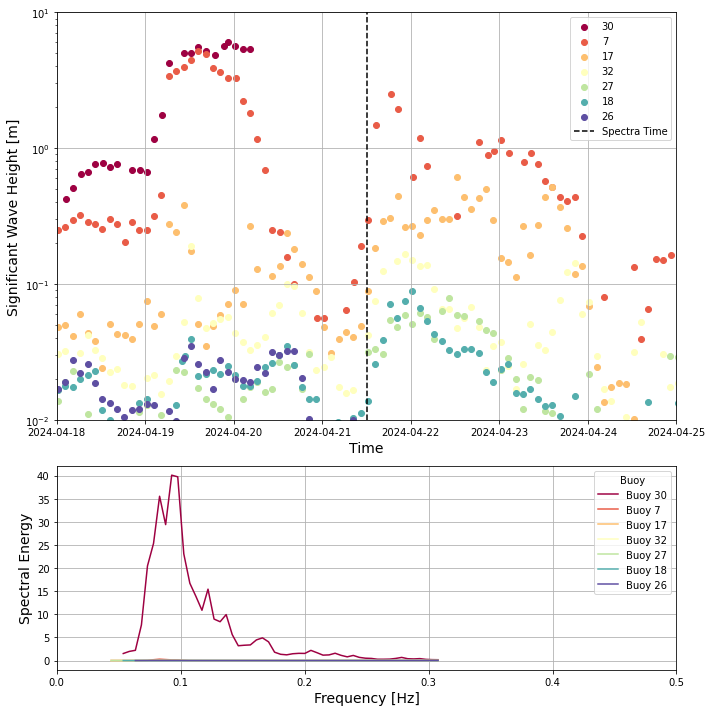

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # For datetime conversion
import matplotlib.cm as cm

# Define the time range for the plot
start_time = pd.to_datetime("2024-04-18")
end_time = pd.to_datetime("2024-04-25")
specific_time = pd.to_datetime("2024-04-21 12:00")

# List of buoy numbers
buoy_list = [30, 7, 17, 32, 27, 18, 26]

# Create a colormap (light blue to dark blue)
colors = cm.Spectral(np.linspace(0, 1, len(buoy_list)))

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})
axes = axes.ravel()

# Subplot 1: Time series plot
for i, buoyno in enumerate(buoy_list):
    color = colors[i]
    # Convert time series to NumPy array for compatibility
    time_series = OMBraw.time_waves_imu[buoyno, :].values
    axes[0].scatter(time_series, OMBraw.pHs0[buoyno, :], label=str(buoyno), color=color)

axes[0].set_xlim([start_time, end_time])
axes[0].set_ylim([0.01, 10])
axes[0].set_yscale('log')
axes[0].set_xlabel("Time", fontsize=14)
axes[0].set_ylabel("Significant Wave Height [m]", fontsize=14)
axes[0].legend(title="Buoy")
axes[0].grid(True)

# Add a vertical line to indicate the specific time
axes[0].axvline(specific_time, color='black', linestyle='--', label='Spectra Time')
axes[0].legend()

# Subplot 2: Spectra plot at a specific time
for i, buoyno in enumerate(buoy_list):
    color = colors[i]
    
    # Extract the time series and convert to NumPy array
    time_series = OMBraw.time_waves_imu[buoyno, :].values
    
    # Ensure specific_time is in a compatible format (numpy.datetime64)
    specific_time_np = np.datetime64(specific_time)
    
    # Find the index corresponding to the specific time
    tt = np.argmin(np.abs(time_series - specific_time_np))  # Find closest time index
    
    # Extract spectral data for the specific time
    spectra = OMBraw.processed_elevation_energy_spectrum[buoyno, tt,:]  # Precomputed spectral energy
    freqs = OMBraw.frequencies_waves_imu.values  # Extract frequency array as NumPy array if xarray object
    
    # Plot the spectral data
    axes[1].plot(freqs, spectra, label=f"Buoy {buoyno}", color=color)

axes[1].set_xlabel("Frequency [Hz]", fontsize=14)
axes[1].set_ylabel("Spectral Energy", fontsize=14)
axes[1].set_xlim([0, 0.5])  # Adjust frequency range as needed
axes[1].grid(True)
axes[1].legend(title="Buoy")

# Tight layout and save the plot
plt.tight_layout()
plt.savefig("combined_plot.png", dpi=300, bbox_inches='tight')
plt.show()



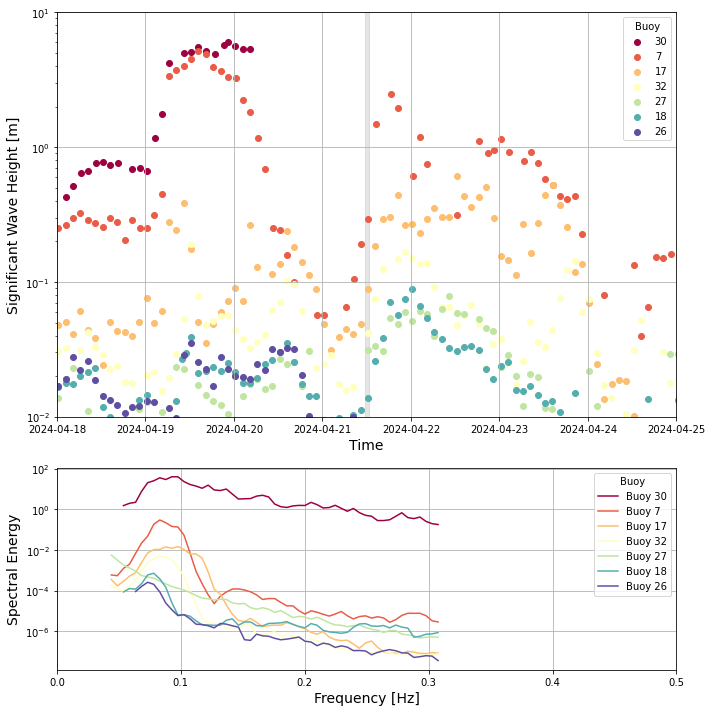

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd  # For datetime conversion
import matplotlib.cm as cm
from matplotlib.patches import Rectangle

# Define the time range for the plot
start_time = pd.to_datetime("2024-04-18")
end_time = pd.to_datetime("2024-04-25")
specific_time = pd.to_datetime("2024-04-21 12:00")

# List of buoy numbers
buoy_list = [30, 7, 17, 32, 27, 18, 26]

# Create a colormap (light blue to dark blue)
colors = cm.Spectral(np.linspace(0, 1, len(buoy_list)))

# Create a figure with two subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})
axes = axes.ravel()

# Subplot 1: Time series plot
for i, buoyno in enumerate(buoy_list):
    color = colors[i]
    # Convert time series to NumPy array for compatibility
    time_series = OMBraw.time_waves_imu[buoyno, :].values
    axes[0].scatter(time_series, OMBraw.pHs0[buoyno, :], label=str(buoyno), color=color)

# Add a grey stripe at the specific time
stripe_width = pd.Timedelta(hours=1)  # Width of the grey stripe
stripe_start = specific_time - stripe_width / 2
stripe_end = specific_time + stripe_width / 2
axes[0].add_patch(Rectangle(
    (stripe_start, 0.01),   # Bottom-left corner (time, min height)
    stripe_width,           # Width
    10,                     # Height (matches y-axis range)
    color='grey',
    alpha=0.2,              # Transparency
    zorder=0                # Ensures the stripe is behind scatter points
))

axes[0].set_xlim([start_time, end_time])
axes[0].set_ylim([0.01, 10])
axes[0].set_yscale('log')  # Logarithmic scale for y-axis
axes[0].set_xlabel("Time", fontsize=14)
axes[0].set_ylabel("Significant Wave Height [m]", fontsize=14)
axes[0].legend(title="Buoy")
axes[0].grid(True)

# Subplot 2: Spectra plot at a specific time
for i, buoyno in enumerate(buoy_list):
    color = colors[i]
    
    # Extract the time series and convert to NumPy array
    time_series = OMBraw.time_waves_imu[buoyno, :].values
    
    # Ensure specific_time is in a compatible format (numpy.datetime64)
    specific_time_np = np.datetime64(specific_time)
    
    # Find the index corresponding to the specific time
    tt = np.argmin(np.abs(time_series - specific_time_np))  # Find closest time index
    
    # Extract spectral data for the specific time
    spectra = OMBraw.processed_elevation_energy_spectrum[buoyno, tt, :]  # Precomputed spectral energy
    freqs = OMBraw.frequencies_waves_imu.values  # Extract frequency array as NumPy array if xarray object
    
    # Plot the spectral data
    axes[1].plot(freqs, spectra, label=f"Buoy {buoyno}", color=color)

axes[1].set_xlabel("Frequency [Hz]", fontsize=14)
axes[1].set_ylabel("Spectral Energy", fontsize=14)
axes[1].set_xlim([0, 0.5])  # Adjust frequency range as needed
axes[1].set_yscale('log')   # Logarithmic scale for y-axis
axes[1].grid(True)
axes[1].legend(title="Buoy")

# Tight layout and save the plot
plt.tight_layout()
plt.savefig("combined_plot_with_stripe.png", dpi=300, bbox_inches='tight')
plt.show()
